<a href="https://colab.research.google.com/github/Shraddha-Bankar/AI_Powered_Demand_Forecasting_-_Demand_Distribution_Dashboard/blob/main/Time_Series_Demand_Forecast1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet xgboost plotly -q

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/retail_demand_dataset.csv")

In [4]:
df.head()

,date,store,item,price,promotion,inventory,sales
0,2022-01-01,1,1,477.82,0,118,24
1,2022-01-01,1,2,200.17,0,72,29
2,2022-01-01,1,3,75.39,0,46,25
3,2022-01-01,1,4,132.53,0,120,25
4,2022-01-01,1,5,53.18,0,87,26


In [5]:
df.shape

(146000, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146000 entries, 0 to 145999
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       146000 non-null  object 
 1   store      146000 non-null  int64  
 2   item       146000 non-null  int64  
 3   price      146000 non-null  float64
 4   promotion  146000 non-null  int64  
 5   inventory  146000 non-null  int64  
 6   sales      146000 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 7.8+ MB


In [7]:
df.describe()

,store,item,price,promotion,inventory,sales
count,146000.000000,146000.000000,146000.000000,146000.000000,146000.000000,146000.000000
mean,5.500000,10.500000,275.027522,0.200493,95.247493,35.810842
std,2.872291,5.766301,129.587343,0.400371,25.307067,10.330824
min,1.000000,1.000000,50.000000,0.000000,29.000000,4.000000
25%,3.000000,5.750000,163.090000,0.000000,75.000000,28.000000
50%,5.500000,10.500000,274.895000,0.000000,95.000000,35.000000
75%,8.000000,15.250000,386.922500,0.000000,115.000000,42.000000
max,10.000000,20.000000,500.000000,1.000000,181.000000,88.000000


In [8]:
df.isnull().sum()

,0
date,0
store,0
item,0
price,0
promotion,0
inventory,0
sales,0


In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df = df.sort_values("date")

In [11]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["dayofweek"] = df["date"].dt.dayofweek

df["quarter"] = df["date"].dt.quarter

df["weekofyear"] = df["date"].dt.isocalendar().week

In [12]:
daily_sales = df.groupby("date")["sales"].sum()

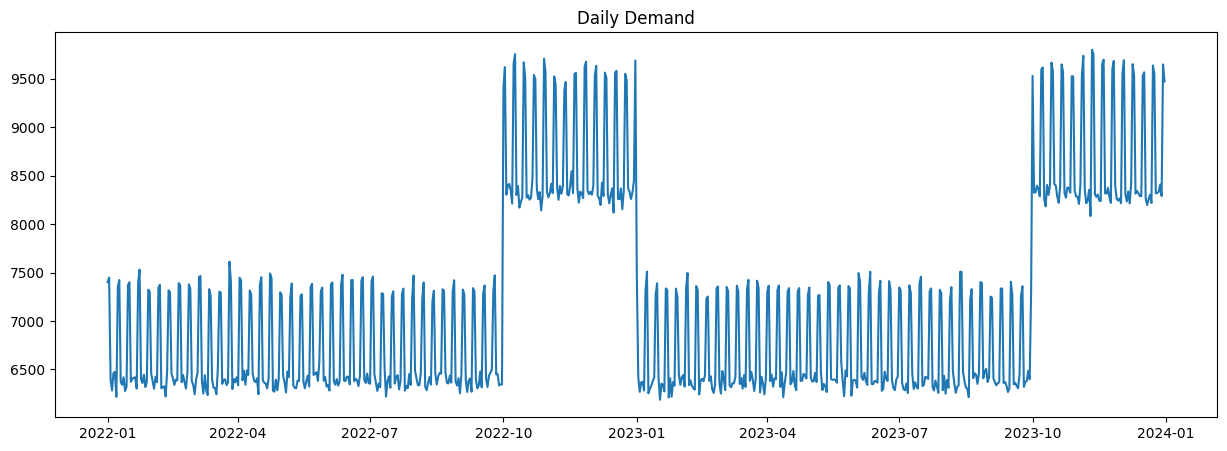

In [13]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales)

plt.title("Daily Demand")

plt.show()

In [14]:
monthly_sales = daily_sales.resample("M").sum()

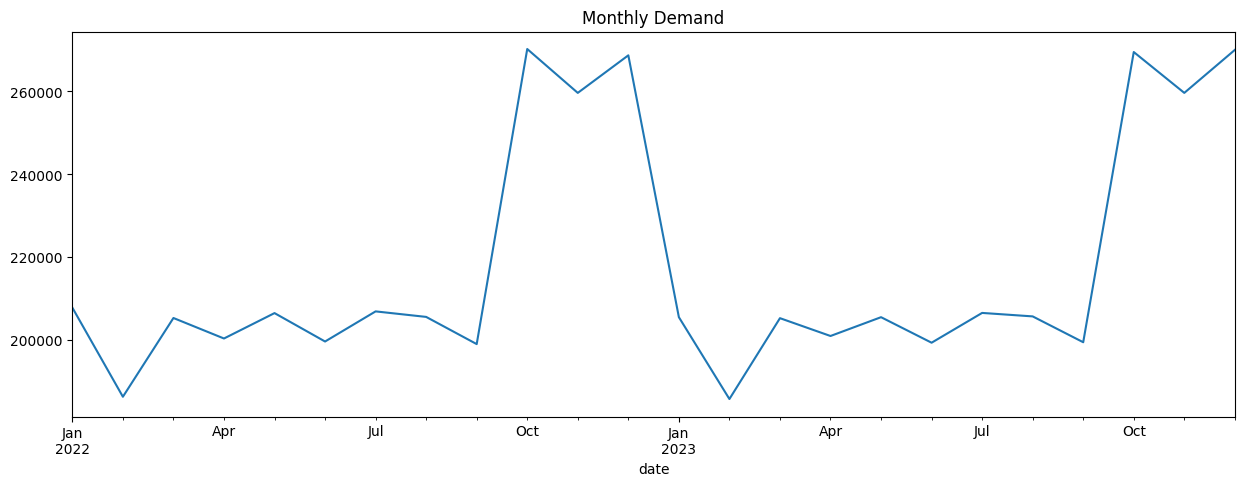

In [15]:
plt.figure(figsize=(15,5))

monthly_sales.plot()

plt.title("Monthly Demand")

plt.show()

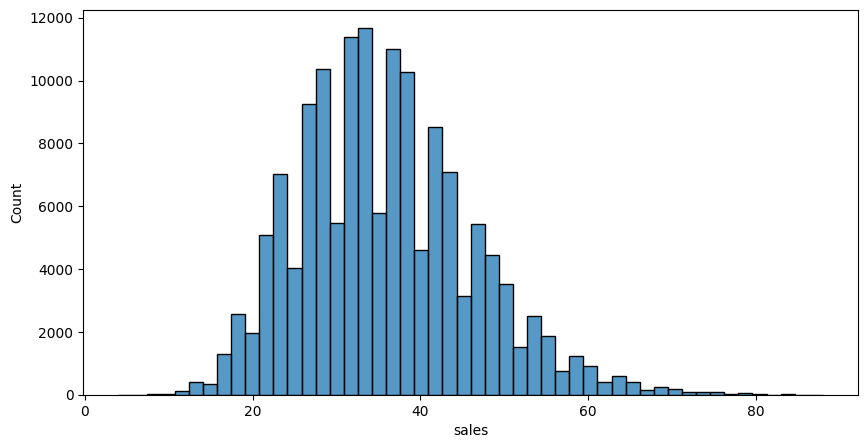

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["sales"], bins=50)

plt.show()


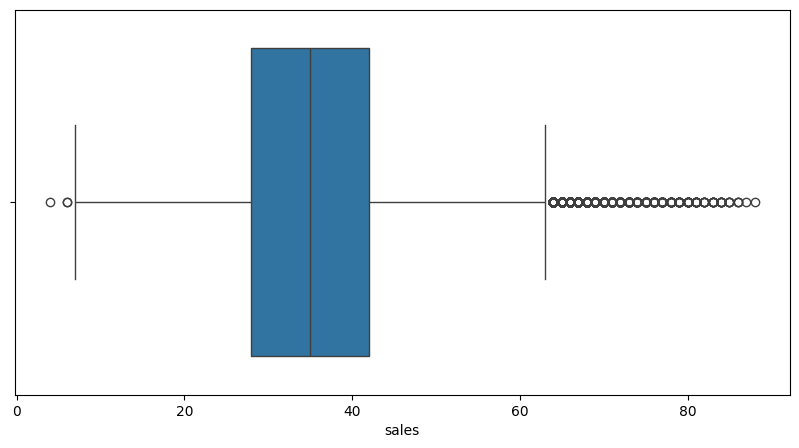

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["sales"])

plt.show()

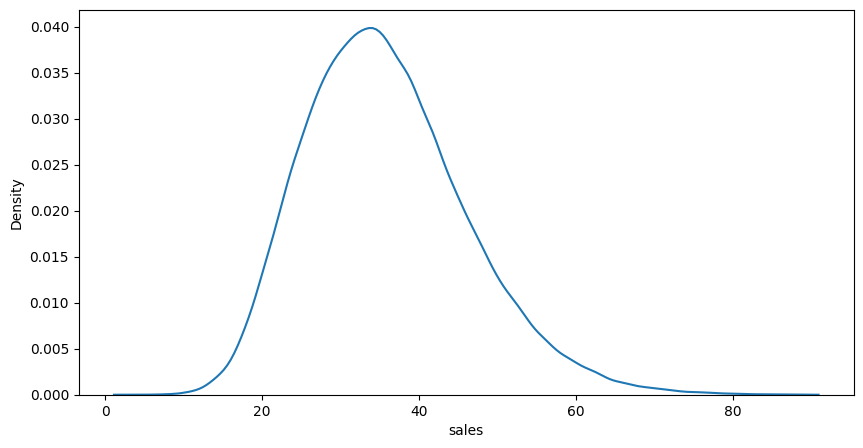

In [18]:
plt.figure(figsize=(10,5))

sns.kdeplot(df["sales"])

plt.show()

In [19]:
store_sales = df.groupby("store")["sales"].sum()

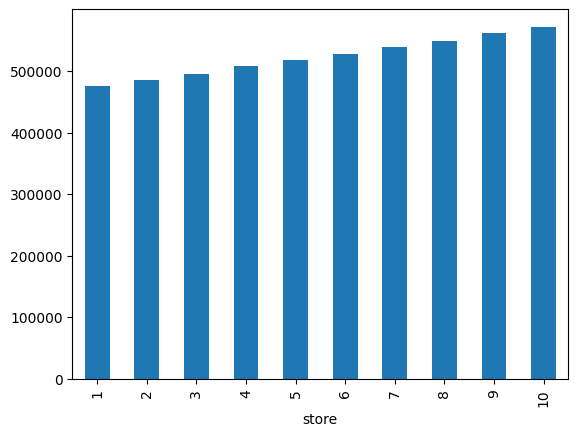

In [20]:
store_sales.plot(kind="bar")

plt.show()

In [21]:
item_sales = (
    df.groupby("item")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

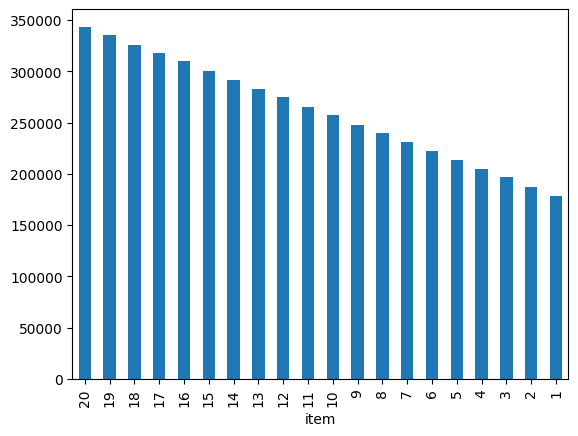

In [22]:
item_sales.plot(kind="bar")

plt.show()

In [23]:
df["lag_7"] = df.groupby(
    ["store","item"]
)["sales"].shift(7)

df["lag_30"] = df.groupby(
    ["store","item"]
)["sales"].shift(30)

In [24]:
df["rolling_7"] = (
    df.groupby(["store","item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_30"] = (
    df.groupby(["store","item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [25]:
df.dropna(inplace=True)

In [26]:
train = df[df["date"] < "2022-12-01"]
test = df[df["date"] >= "2022-12-01"]

In [27]:
features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "dayofweek",
    "quarter",
    "lag_7",
    "lag_30",
    "rolling_7",
    "rolling_30"
]

In [28]:
X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

In [29]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
pred = model.predict(X_test)

In [31]:
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 4.476276397705078
RMSE : 5.6783501101239375
R2 : 0.7126259803771973


In [32]:
importance = pd.DataFrame({
    "Feature":features,
    "Importance":model.feature_importances_
})

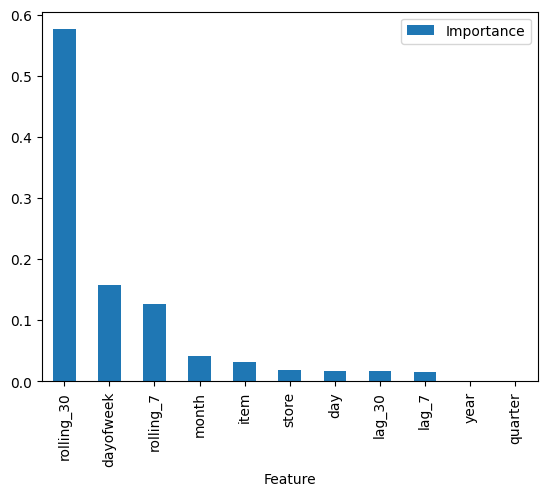

In [33]:
importance.sort_values(
    "Importance",
    ascending=False
).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.show()

In [34]:
prophet_df = (
    df.groupby("date")["sales"]
      .sum()
      .reset_index()
)

In [35]:
prophet_df.columns = [
    "ds",
    "y"
]

In [36]:
m = Prophet()

m.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [37]:
future = m.make_future_dataframe(
    periods=90
)

In [38]:
forecast = m.predict(future)

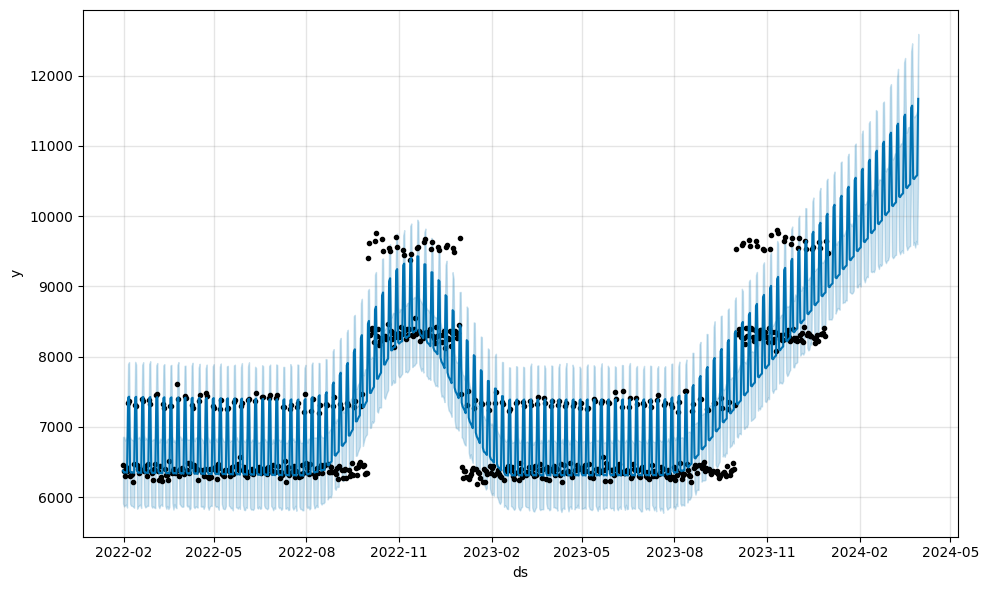

In [39]:
fig = m.plot(forecast)
plt.show()

In [40]:
merged_df = pd.merge(forecast, prophet_df, on='ds', how='inner')

mae_prophet = mean_absolute_error(merged_df['y'], merged_df['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(merged_df['y'], merged_df['yhat']))
r2_prophet = r2_score(merged_df['y'], merged_df['yhat'])

print(f"Prophet Model MAE: {mae_prophet:.2f}")
print(f"Prophet Model RMSE: {rmse_prophet:.2f}")
print(f"Prophet Model R2 Score: {r2_prophet:.2f}")

Prophet Model MAE: 243.64
Prophet Model RMSE: 374.36
Prophet Model R2 Score: 0.87


In [41]:
import joblib

joblib.dump(
    model,
    "demand_forecast.pkl"
)

['demand_forecast.pkl']

In [42]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.title(
    "Demand Forecast Dashboard"
)

model = joblib.load(
    "demand_forecast.pkl"
)

st.write(
    "AI Demand Prediction System"
)

# Assuming you want to run the streamlit app
# If you run this cell, it will save app.py and then try to run streamlit
# You might need to install streamlit-nightly if you face issues with running it directly in Colab

# To run the Streamlit app, you would typically execute the following in a new cell:
# !streamlit run app.py


Writing app.py


In [43]:
!pip install streamlit -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 3s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙

your url is: https://poor-suits-spend.loca.lt
2026-05-31 12:51:55.600 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.254.135.151:8501

